In [92]:
import torch
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

path = '../neural_model_identification/data_module/trajectories/sample_0'
traj = np.load(path + '/states.npy')
actions = np.load(path + '/actions.npy')
delta_t = 0.3

print("trajectory shape: ",traj.shape)
print("actions shape: ",actions.shape)
actions = np.concatenate([actions, np.array([[0, 0]])]) # directly set the last action to zero (solve a shape problem) 
print("actions shape: ",actions.shape)
input = torch.concatenate((torch.from_numpy(traj), torch.from_numpy(actions)), axis=1).float()

trajectory shape:  (1001, 3)
actions shape:  (1000, 2)
actions shape:  (1001, 2)


In [135]:
def ode_system(input, output):
    # x is assumed to be my input: [x, y, theta, v, w, t]
    # y is assumed to be my output: [x_next, y_next, theta_next]
    #print('x shape: ', input.shape)
    #print('y shape: ', output.shape)
    
    x, y, theta, v, w = input[:, 0:1], input[:, 1:2], input[:, 2:3], input[:, 3:4], input[:, 4:5] # these have shape (something, 1)

    dx_t = dde.grad.jacobian(output, input, i=0, j=5) # time derivative of X
    dy_t = dde.grad.jacobian(output, input, i=1, j=5) # time derivative of Y
    dtheta_t = dde.grad.jacobian(output, input, i=2, j=5) # time derivative of Theta

    return [dx_t - v*torch.cos(theta), dy_t - v*torch.sin(theta), dtheta_t - w]

def boundary(x, on_initial):
    return on_initial and dde.utils.isclose(x[5], 0)

def uniKin(state):
    # print('state_shape original: ' , state.shape)
    x, u = state[:, :3], state[:, 3:]

    x_dot = u[:, 0:1]*np.cos(x[:, 2:3])
    y_dot = u[:, 0:1]*np.sin(x[:, 2:3])
    theta_dot = u[:, 1:2]
    return np.hstack((x_dot, y_dot, theta_dot))

#---------------------------
# TODO check if this are correct
x_lim = [-100.0, 100.0]
y_lim = [-100.0, 100.0]
theta_lim = [0.0, 2*np.pi]
v_lim = [-1.0, 1.0]
w_lim = [-1.0, 1.0]
geom = dde.geometry.Hypercube([x_lim[0], y_lim[0], theta_lim[0], v_lim[0], w_lim[0]], 
                              [x_lim[1], y_lim[1], theta_lim[1], v_lim[1], w_lim[1]])
timedomain = dde.geometry.TimeDomain(0, delta_t)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

# TODO define the boundary conditions

ic_list = []
num_input = 6 # x_k y_k theta_k v_k w_k t_k (time is directly handled by geomtime)
num_output = 3 # x_k+1 y_k+1 theta_k+1
net = dde.nn.FNN([num_input] + [50] * 3 + [num_output], "tanh", "Glorot uniform")
data = dde.data.PDE(geomtime, ode_system, ic_list, 2000, 200, solution=uniKin)
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["mean squared error"])
losshistory, train_state = model.train(iterations=20000)

Compiling model...
'compile' took 0.000292 s

Training model...

0         [1.73e-01, 1.70e-01, 3.45e-01]    [1.73e-01, 1.70e-01, 3.45e-01]    [4.82e-01]
1000      [5.71e-03, 7.09e-03, 5.01e-03]    [5.71e-03, 7.09e-03, 5.01e-03]    [1.39e+01]
2000      [2.00e-03, 2.15e-03, 1.54e-03]    [2.00e-03, 2.15e-03, 1.54e-03]    [1.70e+01]
3000      [1.24e-03, 1.46e-03, 1.04e-03]    [1.24e-03, 1.46e-03, 1.04e-03]    [1.98e+01]
4000      [8.78e-04, 1.09e-03, 6.50e-04]    [8.78e-04, 1.09e-03, 6.50e-04]    [2.26e+01]
5000      [6.77e-04, 8.14e-04, 5.01e-04]    [6.77e-04, 8.14e-04, 5.01e-04]    [2.53e+01]
6000      [6.47e-04, 7.31e-04, 4.14e-04]    [6.47e-04, 7.31e-04, 4.14e-04]    [2.72e+01]
7000      [4.91e-04, 5.24e-04, 3.41e-04]    [4.91e-04, 5.24e-04, 3.41e-04]    [2.82e+01]
8000      [4.40e-04, 4.51e-04, 3.09e-04]    [4.40e-04, 4.51e-04, 3.09e-04]    [2.89e+01]
9000      [3.77e-04, 3.82e-04, 2.52e-04]    [3.77e-04, 3.82e-04, 2.52e-04]    [2.98e+01]
10000     [3.95e-04, 4.19e-04, 5.80e-04]    [

In [136]:
gen_x = []
for i in range(len(input)):
    gen_x.append(model.predict( torch.concatenate((input[i],torch.tensor([delta_t*i]))) ))

generated_traj = np.asarray(gen_x)

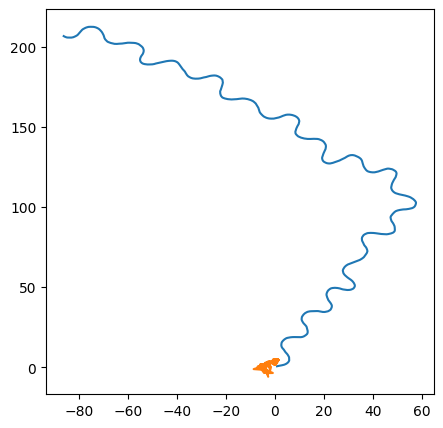

In [140]:
plt.figure(figsize=(5,5))
plt.plot(traj[:, 0], traj[: ,1])
plt.plot(generated_traj[:,0], generated_traj[:,1])
plt.show()

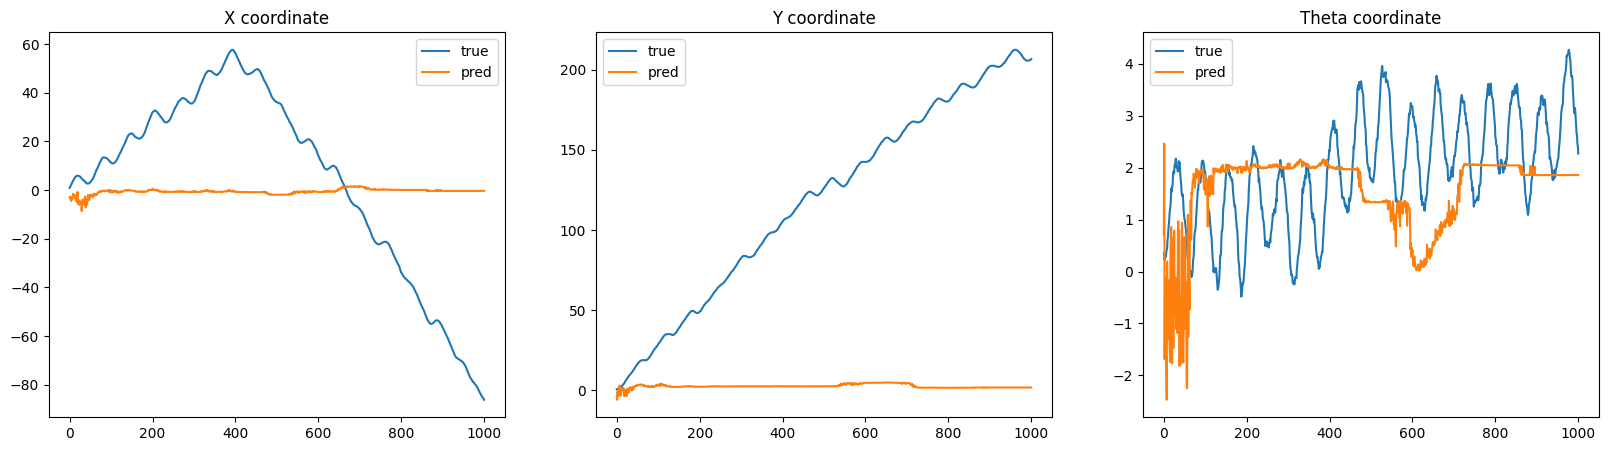

In [141]:
fig, axs = plt.subplots(1, 3)
axs[0].plot(traj[:,0], label='true')
axs[0].plot(generated_traj[:,0], label='pred')
axs[0].set_title('X coordinate')
axs[1].plot(traj[:,1], label='true')
axs[1].plot(generated_traj[:,1], label='pred')
axs[1].set_title('Y coordinate')
axs[2].plot(traj[:,2], label='true')
axs[2].plot(generated_traj[:,2], label='pred')
axs[2].set_title('Theta coordinate')
fig.set_figheight(5)
fig.set_figwidth(20)
axs[0].legend()
axs[1].legend()
axs[2].legend()